# 🚦 Lab 2: Traffic Sign Classification & Experiment Management
### ELEC5308 – Intelligent Information Engineering Practice
**University of Sydney | School of Electrical and Computer Engineering**

---

## 🎯 Lab Objectives
By the end of this lab you will be able to:
1. **Load and explore** the GTSRB traffic-sign dataset (43 classes, ~52 k images).
2. **Implement data preprocessing** pipelines with augmentation transforms.
3. **Construct a CNN** from building blocks (`ConvBlock`, `ResidualBlock`) provided in the `elec5308` package.
4. **Train your model** and log metrics to a **CometML** experiment dashboard.
5. **Evaluate** your classifier using accuracy, precision, recall, F1 (macro / micro / weighted) and a confusion matrix.
6. **Fine-tune a pretrained ResNet** using transfer learning and compare experiments in CometML.

---

## 📦 Repository Structure
```
lab2-elec5308/
├── elec5308/               ← Python package (provided – do NOT modify)
│   ├── datasets.py         ← GTSRB loader & class registry
│   ├── models.py           ← ConvBlock, ResidualBlock, SimpleCNN, get_pretrained_resnet
│   ├── metrics.py          ← compute_metrics, plot_confusion_matrix
│   ├── trainer.py          ← Trainer class with CometML hooks
│   └── visualisation.py   ← Plotting utilities
├── lab2_notebook.ipynb    ← THIS file – your working lab notebook
└── README.md               ← This file :-)
```

> **Assessment:** This lab contributes to **Lab Milestones (5%)** and the **Lab Quiz (10%)**.  
> Submit via GitHub before the deadline shown on Canvas.  
> If you use AI tools, you **must** complete proper AI Journal entries.


---
## Section 0 — Environment Setup ✅ *Provided – just run all cells in this section*

This section installs dependencies, configures your device, and initialises
a **CometML** experiment that will track every metric you log during training.

> **What is CometML?**  
> CometML is an MLOps platform that automatically tracks your experiments:
> hyperparameters, metrics, code, and model artefacts.  
> Think of it as a lab notebook that never loses data.


In [2]:
# Install / upgrade required packages
# You could also install these packages manually using pip, e.g.:
# %pip install torch torchvision comet-ml scikit-learn matplotlib seaborn pandas tqdm torchinfo
# However, on Gradescope, %pip installs are skipped.
import subprocess, sys
packages = [
    "torch torchvision",
    "comet-ml",
    "scikit-learn",
    "matplotlib seaborn",
    "pandas tqdm",
    "torchinfo",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkg.split())
print("All packages installed.")

All packages installed.


In [3]:
# Importing required libraries
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110

import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader

from sklearn.metrics import ConfusionMatrixDisplay

# Let's import our custom library for this lab
# It provides functions for loading the GTSRB dataset, defining CNN models, training, and evaluation.
# Try to use those functions for your Assignment 1.
import sys; sys.path.insert(0, "..")  # Allow import from repo root
from elec5308 import (
    GTSRBDataset, load_gtsrb, GTSRB_CLASSES, NUM_CLASSES, get_class_name,
    ConvBlock, ResidualBlock, SimpleCNN, get_pretrained_resnet, count_parameters,
    compute_metrics, plot_confusion_matrix, classification_report_df,
    Trainer,
    show_sample_images, plot_class_distribution, plot_training_history,
)

# Lab computers have GPUs, but if you're running this notebook on your own computer,
# you may not have a GPU. If you are running this notebook on Colab, you can enable
# GPU acceleration by going to "Runtime" -> "Change runtime type" and selecting
# "GPU" as the hardware accelerator. However, note that on Colab, you need to install
# the elec5308 library, as simple as a `git clone URL` command. Ask Ali or your
# lab demonstrator for help if you want to run this notebook on Colab.
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():   # Apple Silicon
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")
print(f"GTSRB has {NUM_CLASSES} traffic-sign classes")


Using device: cpu
GTSRB has 43 traffic-sign classes


### 0.1 — CometML Setup

Follow these steps **before running the cell below**:

1. Go to [comet.ml](https://www.comet.ml) → create a **free** account (You can use any email address).
2. Navigate to **Settings → API Keys** → copy your key.
3. Paste it into the cell below where it says `"YOUR_API_KEY_HERE"`.
4. Set your `workspace` to your CometML username.

> 💡 **Pro Tip:** Store your API key as an environment variable (`COMET_API_KEY`) instead of hard-coding it.  In a terminal: `export COMET_API_KEY="your-key"`. You can also store it inside a `.env` file. [Read more](https://help.openai.com/en/articles/5112595-best-practices-for-api-key-safety)


In [4]:
# This block shows you the full CometML setup pattern.
# You will replicate this for the Transfer Learning task (Section 6).

import comet_ml
# Option A: read from environment variable (recommended)
COMET_API_KEY  = "cq5tIyWVov5Iyhor4heJsrReI" # os.environ.get("COMET_API_KEY", "YOUR_API_KEY_HERE")
COMET_PROJECT  = "elec5308-lab2"
COMET_WORKSPACE = "tanmay-rale"   # ← replace with your Comet username

experiment = comet_ml.Experiment(
    api_key=COMET_API_KEY,
    project_name=COMET_PROJECT,
    workspace=COMET_WORKSPACE,
    auto_param_logging=True,
    auto_metric_logging=False,  # We log manually for full control
)

# Tag this experiment for easy filtering in the dashboard
experiment.add_tags(["lab2", "baseline-cnn", "gtsrb"])
experiment.set_name("SimpleCNN-baseline")

print("CometML experiment created!")
print(f"View at: {experiment.url}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/tanmay-rale/elec5308-lab2/1dd0ed01ad694d968e7b30a217044ca7



CometML experiment created!
View at: https://www.comet.com/tanmay-rale/elec5308-lab2/1dd0ed01ad694d968e7b30a217044ca7


### 0.2 — Load the GTSRB Dataset ✅

The dataset downloads automatically on first run (~300 MB).  
Subsequent runs use the cached version.


In [5]:
# Load raw dataset for exploration
gtsrb = GTSRBDataset(root="./data", image_size=32, use_imagenet_stats=False)

# Quick sanity check
print(f"\nTraining samples : {len(gtsrb.train_raw):,}")
print(f"Test samples     : {len(gtsrb.test_raw):,}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"\nFirst 5 class names:")
for i in range(5):
    print(f"  [{i:2d}] {get_class_name(i)}")

# Let's log this information to CometML as well
experiment.log_parameter("num_train_samples", len(gtsrb.train_raw))
experiment.log_parameter("num_test_samples", len(gtsrb.test_raw))
experiment.log_parameter("num_classes", NUM_CLASSES)

📦 Loading GTSRB dataset (image_size=32×32) …


100%|██████████| 187M/187M [01:13<00:00, 2.56MB/s] 
100%|██████████| 89.0M/89.0M [00:16<00:00, 5.44MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 120kB/s] 

✅ GTSRB loaded — train: 26,640 images | test: 12,630 images | classes: 43

Training samples : 26,640
Test samples     : 12,630
Number of classes: 43

First 5 class names:
  [ 0] Speed limit (20 km/h)
  [ 1] Speed limit (30 km/h)
  [ 2] Speed limit (50 km/h)
  [ 3] Speed limit (60 km/h)
  [ 4] Speed limit (70 km/h)


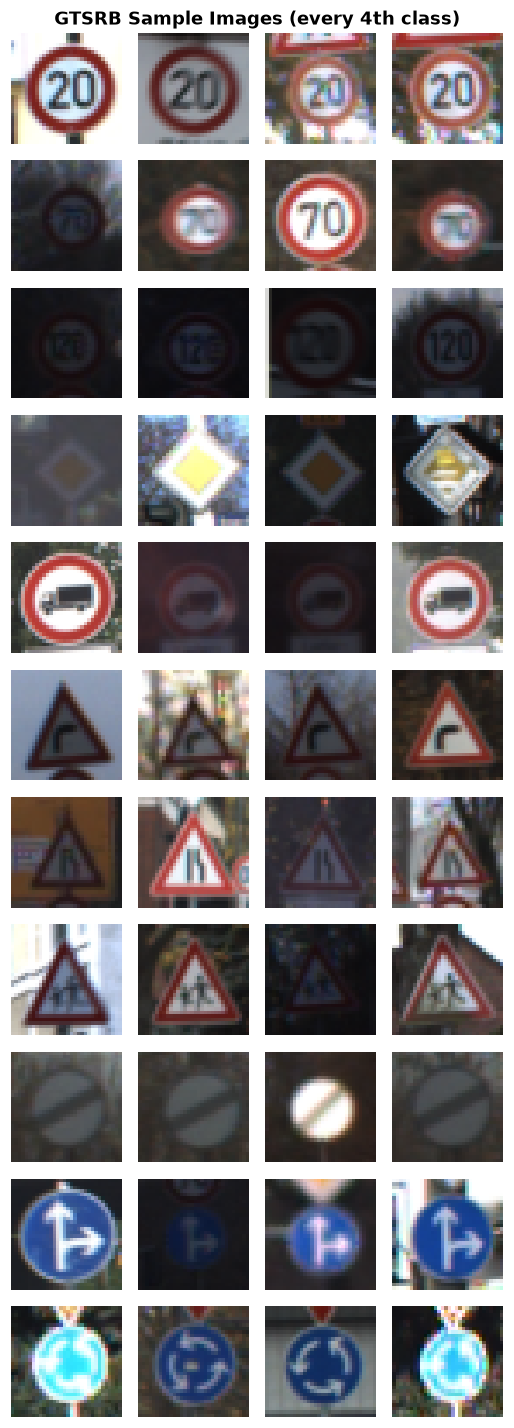

In [6]:
# shows 4 samples for a selection of 10 classes
fig = show_sample_images(
    gtsrb.train_raw,
    class_names=list(GTSRB_CLASSES.values()),
    n_per_class=4,
    classes_to_show=list(range(0, 43, 4)),   # every 4th class
    title="GTSRB Sample Images (every 4th class)",
)
# Let's log this image to CometML as well
experiment.log_figure(figure_name="GTSRB Sample Images", figure=fig)
plt.show()

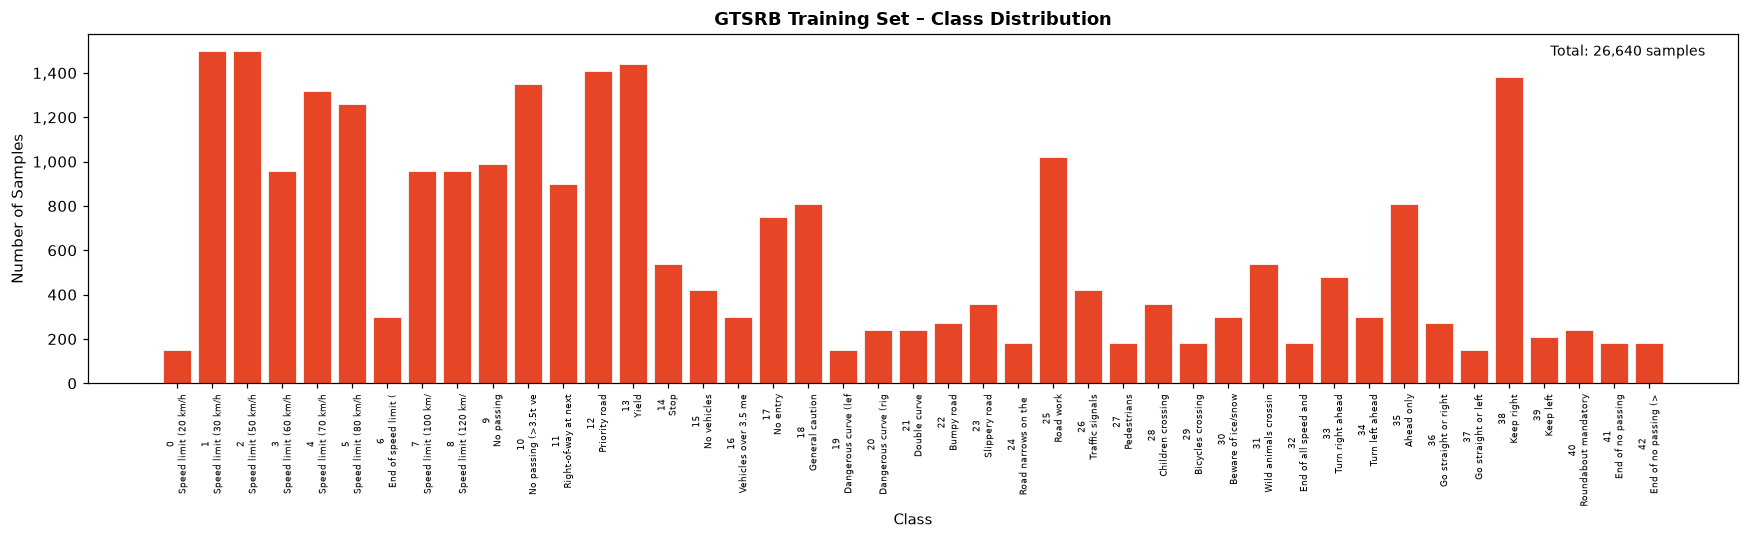


Most common class: 1 (Speed limit (30 km/h)) - 1500 samples
Rarest class     : 0 (Speed limit (20 km/h)) - 150 samples


In [9]:
# Class distribution
train_labels = gtsrb.get_class_labels(split="train")
fig = plot_class_distribution(
    train_labels,
    class_names=list(GTSRB_CLASSES.values()),
    title="GTSRB Training Set – Class Distribution",
)
# Save and log the class-distribution image to CometML
class_distribution_path = "class_distribution.png"
fig.savefig(class_distribution_path, dpi=150, bbox_inches="tight")
plt.show()
experiment.log_image(
    class_distribution_path,
    name="GTSRB Training Class Distribution",
)

# Report useful class-balance information
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
most_common_idx = int(class_counts.argmax())
rarest_idx = int(class_counts.argmin())

print(
    f"\nMost common class: {most_common_idx} "
    f"({get_class_name(most_common_idx)}) - {class_counts[most_common_idx]} samples"
)
print(
    f"Rarest class     : {rarest_idx} "
    f"({get_class_name(rarest_idx)}) - {class_counts[rarest_idx]} samples"
)

experiment.log_parameters({
    "most_common_class": most_common_idx,
    "most_common_class_count": int(class_counts[most_common_idx]),
    "rarest_class": rarest_idx,
    "rarest_class_count": int(class_counts[rarest_idx]),
})

---
## Section 2 — Task 1: Data Preprocessing 🔨 *Your turn*

### Background
Raw GTSRB images come in varying sizes.  Before feeding them to a neural
network we must:

1. **Resize** every image to a fixed spatial resolution.
2. **Normalise** pixel values so the network sees inputs in a stable range.
3. **Augment** the training set to improve generalisation (the validation and
   test sets must **not** be augmented).

Common augmentation strategies for traffic signs:
- Random horizontal/vertical flips *(caution: some signs are not symmetric!)*
- Random rotation (small angle - traffic signs are roughly upright)
- Colour jitter (brightness, contrast) - simulate day/dusk/shadow
- Random cropping / perspective distortion

> **From the lecture:** "*The true test of a model is how well it generalises to unseen examples.*"  
> Augmentation artificially expands the training distribution.

### ✏️ Your Tasks
- [ ] **2a** Define a **training transform** with at least **three augmentations**. [A comprehensive list of all available transformations](https://docs.pytorch.org/vision/main/transforms.html#v2-api-reference-recommended)
- [ ] **2b** Define a **validation/test transform** (normalise only, no augmentation).
- [ ] **2c** Create **DataLoaders** and verify the batch shape.

In [10]:
# 2a: Training Transform
# Traffic-sign-safe augmentation: small geometric and colour changes only.
# We intentionally avoid horizontal / vertical flips because they can change
# the meaning of directional traffic signs.

IMAGE_SIZE = 32

train_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Augmentation 1: signs may appear slightly tilted
    T.RandomRotation(degrees=10),

    # Augmentation 2: simulate small camera-position / scale changes
    T.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.90, 1.10),
    ),

    # Augmentation 3: simulate illumination / colour variation
    T.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.10,
    ),

    T.ToTensor(),
    T.Normalize(
        mean=(0.3403, 0.3121, 0.3214),
        std=(0.2724, 0.2608, 0.2669),
    ),
])

print("Train transform defined:", train_transform)


Train transform defined: Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.08, 0.08), scale=(0.9, 1.1))
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=(0.3403, 0.3121, 0.3214), std=(0.2724, 0.2608, 0.2669))
)


In [25]:
# 2b: Validation / Test Transform
# Remember: NO augmentation on validation or test sets!

eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=(0.3403, 0.3121, 0.3214),
        std=(0.2724, 0.2608, 0.2669),
    ),
])

print("Eval transform defined:", eval_transform)


Eval transform defined: Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.3403, 0.3121, 0.3214), std=(0.2724, 0.2608, 0.2669))
)


In [26]:
# 2c: Create DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 0   # safest for VS Code / Windows / Gradescope
VAL_SPLIT = 0.15

train_loader, val_loader, test_loader = load_gtsrb(
    root="./data",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    val_fraction=VAL_SPLIT,
    train_transform=train_transform,
    eval_transform=eval_transform,
    num_workers=NUM_WORKERS,
    seed=2026,
)

# 2d: Verify batch shape
images, labels = next(iter(train_loader))

print(f"\nBatch shape  : {images.shape}  → (batch, channels, height, width)")
print(f"Labels shape : {labels.shape}")
print(f"Label range  : [{labels.min().item()}, {labels.max().item()}]  (expect [0, 42])")

assert images.ndim == 4, "Expected 4D tensor (B, C, H, W)"
assert images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE), (
    f"Expected image shape (3, {IMAGE_SIZE}, {IMAGE_SIZE}), got {images.shape[1:]}"
)
assert labels.min().item() >= 0 and labels.max().item() <= 42, (
    "Labels should be in [0, 42]"
)

print("\nDataLoaders look correct!")
print(
    f"Dataset sizes: train={len(train_loader.dataset):,}, "
    f"val={len(val_loader.dataset):,}, test={len(test_loader.dataset):,}"
)


✅ DataLoaders ready — train: 22,644 | val: 3,996 | test: 12,630 samples

Batch shape  : torch.Size([32, 3, 32, 32])  → (batch, channels, height, width)
Labels shape : torch.Size([32])
Label range  : [2, 42]  (expect [0, 42])

DataLoaders look correct!
Dataset sizes: train=22,644, val=3,996, test=12,630


> **Anything important to note on the DataLoaders?** You can log them to CometML using `experiment.log_parameter()` if you think it's useful.

In [27]:
# Log important data-pipeline hyperparameters to CometML
experiment.log_parameters({
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "val_split": VAL_SPLIT,
    "image_size": IMAGE_SIZE,
    "train_size": len(train_loader.dataset),
    "val_size": len(val_loader.dataset),
    "test_size": len(test_loader.dataset),
})
experiment.log_text(
    str(train_transform),
    metadata={"context": "data augmentation", "purpose": "train_pipeline"},
)
experiment.log_text(
    str(eval_transform),
    metadata={"context": "data preprocessing", "purpose": "eval_pipeline"},
)


{'web': 'https://www.comet.com/api/asset/download?assetId=4a873d5f10e34298b1aaaf69d8bedf6b&experimentKey=1dd0ed01ad694d968e7b30a217044ca7',
 'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=4a873d5f10e34298b1aaaf69d8bedf6b&experimentKey=1dd0ed01ad694d968e7b30a217044ca7',
 'assetId': '4a873d5f10e34298b1aaaf69d8bedf6b'}

#### Comet Dashboard

Let's look at your Comet dashboard. What is logged there?

---
## Section 3 — Task 2: Build Your CNN 🔨 *Your turn*

### Background
The `elec5308.models` module provides the following building blocks:

| Class | What it does |
|---|---|
| `ConvBlock(in_ch, out_ch, kernel_size, padding, pool)` | Conv → BN (Will be discuused in Week 3) → ReLU (→ MaxPool) |
| `ResidualBlock(in_ch, out_ch, stride)` | Skip-connection block (ResNet-style) |
| `SimpleCNN(num_classes)` | Provided baseline — 3 ConvBlocks + global average pool |

Your task is to **design your own CNN** by assembling these blocks.  You can:
- Use `SimpleCNN` as a starting point and modify it.
- Build from scratch using `ConvBlock` and `ResidualBlock`.
- Add `nn.BatchNorm2d`, `nn.Dropout`, or custom activation functions.

> **On this week's lecture:** We covered ConvBlocks, padding, stride,
> pooling, and classic architectures (LeNet → AlexNet → VGG → ResNet).

### ✏️ Your Tasks
- [ ] **3a** Design a CNN with at least **3 convolutional layers**.
- [ ] **3b** Print the model architecture and count trainable parameters.
- [ ] **3c** Verify the output shape with a dummy forward pass.


In [28]:
# 3a: Define the CNN
# SimpleCNN is the provided baseline and contains three convolutional blocks,
# satisfying the requirement of at least three convolutional layers.

torch.manual_seed(2026)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(2026)

model = SimpleCNN(num_classes=NUM_CLASSES)
model = model.to(DEVICE)

assert model is not None, "Model was not created"
print(model)


SimpleCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=

In [29]:
# 3b: Count parameters
n_params = count_parameters(model)
print(f"Trainable parameters: {n_params:,}")

# Log architecture to CometML
experiment.log_parameter("model_trainable_params", n_params)
experiment.log_parameter("model_name", type(model).__name__)
experiment.log_parameter("model_architecture", str(model))


COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'SimpleCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), pa

Trainable parameters: 137,547


> Did you notice that model definition is truncated as it exceeds 1000 characters? A more proper way is to log the code used to generate the model.

In [31]:
import inspect

# 1. Extract the exact source code of the class
model_class_code = inspect.getsource(model.__class__)

# 2. Log the text block to Comet (it will appear under the Text tab)
experiment.log_code(code=model_class_code, code_name="cnn model")

[('cnn model',
  {'web': 'https://www.comet.com/api/asset/download?assetId=7d5098fb94c748f18825cb7cc9ef985f&experimentKey=1dd0ed01ad694d968e7b30a217044ca7',
   'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=7d5098fb94c748f18825cb7cc9ef985f&experimentKey=1dd0ed01ad694d968e7b30a217044ca7',
   'assetId': '7d5098fb94c748f18825cb7cc9ef985f'})]

In [32]:
# 3c: Verify output shape with a dummy input
dummy = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"Input  shape: {dummy.shape}")
print(f"Output shape: {out.shape}  ← should be (4, {NUM_CLASSES})")
assert out.shape == (4, NUM_CLASSES), f"Expected output shape (4, {NUM_CLASSES}), got {out.shape}"
print("Model output shape is correct!")

Input  shape: torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 43])  ← should be (4, 43)
Model output shape is correct!


---
## Section 4 — Task 3: Train Your Model 🔨 *Your turn*

### Background
Training a neural network involves three steps per mini-batch:
1. **Forward pass** – compute predictions.
2. **Loss** – measure how wrong the predictions are (cross-entropy loss).
3. **Backward pass** – compute gradients and update weights (gradient descent).

The `Trainer` class in `elec5308.trainer` handles this loop and automatically
logs metrics to your CometML experiment.

> **In the lecture**, we covered gradient descent, and learning rate.

### ✏️ Your Tasks
- [ ] **4a** Choose a loss function and optimiser; log hyperparameters to CometML.
- [ ] **4b** Train for at least 15 epochs using the `Trainer`.
- [ ] **4c** Plot the training history and interpret the curves and log it into Comet.


In [33]:
# 4a: Loss function and optimiser

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 15

criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

assert criterion is not None, "Define a loss function"
assert optimiser is not None, "Define an optimiser"
assert N_EPOCHS >= 15, "The lab requires at least 15 training epochs"

# Log hyperparameters to CometML
experiment.log_parameters({
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "n_epochs": N_EPOCHS,
    "batch_size": BATCH_SIZE,
    "image_size": IMAGE_SIZE,
    "val_split": VAL_SPLIT,
    "optimizer": type(optimiser).__name__,
    "loss_function": type(criterion).__name__,
})

print("Hyperparameters logged to CometML")


Hyperparameters logged to CometML


> It's a good idea to see how this information is displayed in your Comet dashboard

In [34]:
# 4b: Train using Trainer

# Optional: add a learning-rate scheduler for smoother training
# scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=5, gamma=0.5)

trainer = Trainer(
    model=model,
    optimiser=optimiser,
    criterion=criterion,
    device=DEVICE,
    experiment=experiment,      # ← CometML experiment for automatic logging
    checkpoint_dir="./checkpoints",
)

history = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=N_EPOCHS,
    # scheduler=scheduler,    # uncomment if using a scheduler (Will be discussed on Week 4)
    save_best=True,
)

# Restore the best model weights
# Yes, this is important! The model at the end of training may
# not be the best one, due to overfitting.
trainer.load_best()



🚀  Starting training on cpu for 15 epochs



  train:   0%|          | 0/708 [00:00<?, ?it/s]

  eval :   0%|          | 0/125 [00:00<?, ?it/s]

Epoch   1/15 | train loss 2.6829  acc 0.2313 | val loss 1.9801  acc 0.3716 | 33.0s ✨ best


  train:   0%|          | 0/708 [00:00<?, ?it/s]

...

  eval :   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  14/15 | train loss 0.1844  acc 0.9433 | val loss 0.0640  acc 0.9797 | 32.3s


  train:   0%|          | 0/708 [00:00<?, ?it/s]

  eval :   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  15/15 | train loss 0.1746  acc 0.9452 | val loss 0.0596  acc 0.9857 | 32.6s ✨ best

✅  Training complete.  Best val accuracy: 0.9857
✅  Loaded best model weights (val_acc=0.9857)


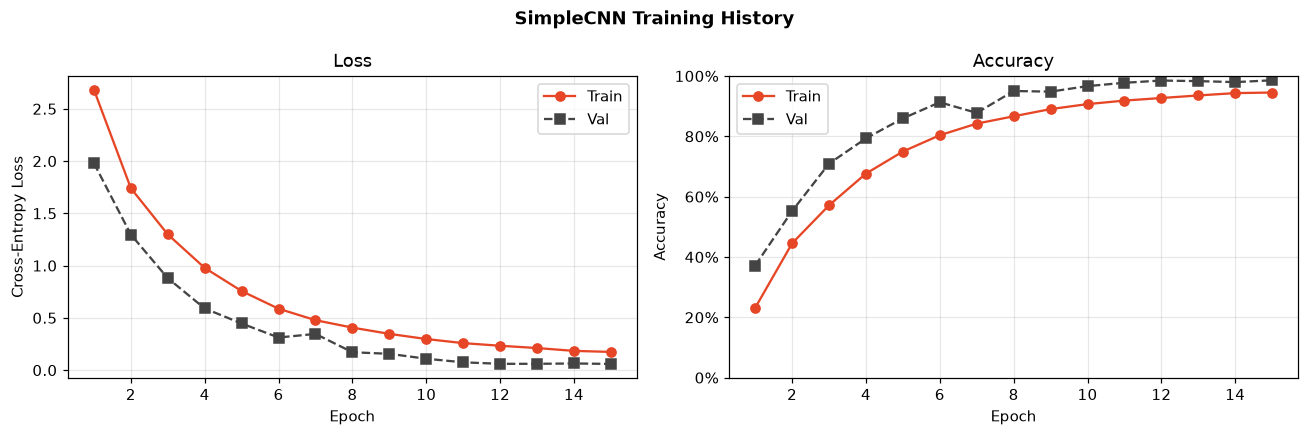


Final train loss : 0.1746
Final train acc  : 94.52%
Final val loss   : 0.0596
Final val acc    : 98.57%
Best val acc     : 98.57% at epoch 15

Curve interpretation:
Training and validation accuracy are reasonably close, suggesting that the model is generalising without a large accuracy gap.


{'web': 'https://www.comet.com/api/asset/download?assetId=2bd270e0955d4b82b43591ee3fb4f2df&experimentKey=1dd0ed01ad694d968e7b30a217044ca7',
 'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=2bd270e0955d4b82b43591ee3fb4f2df&experimentKey=1dd0ed01ad694d968e7b30a217044ca7',
 'assetId': '2bd270e0955d4b82b43591ee3fb4f2df'}

In [35]:
# 4c: Plot training history
fig = plot_training_history(history, title="SimpleCNN Training History")
plt.show()

# Log the figure to CometML
experiment.log_figure("training_curves", fig)

# Final metrics summary
final_train_loss = history["train_loss"][-1]
final_train_acc = history["train_acc"][-1]
final_val_loss = history["val_loss"][-1]
final_val_acc = history["val_acc"][-1]
best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = float(np.max(history["val_acc"]))

print(f"\nFinal train loss : {final_train_loss:.4f}")
print(f"Final train acc  : {final_train_acc:.2%}")
print(f"Final val loss   : {final_val_loss:.4f}")
print(f"Final val acc    : {final_val_acc:.2%}")
print(f"Best val acc     : {best_val_acc:.2%} at epoch {best_epoch}")

# Concise interpretation of the curves
if final_train_acc - final_val_acc > 0.05:
    interpretation = (
        "The training accuracy is noticeably higher than validation accuracy, "
        "which suggests some overfitting. The best validation checkpoint is "
        "therefore more reliable than simply using the final epoch."
    )
elif final_val_acc - final_train_acc > 0.05:
    interpretation = (
        "Validation accuracy is higher than training accuracy. This can happen "
        "because the training images are randomly augmented and therefore harder "
        "than the unaugmented validation images. There is no strong sign of "
        "overfitting from the accuracy gap alone."
    )
else:
    interpretation = (
        "Training and validation accuracy are reasonably close, suggesting that "
        "the model is generalising without a large accuracy gap."
    )

print("\nCurve interpretation:")
print(interpretation)
experiment.log_text(
    interpretation,
    metadata={"context": "training_history_interpretation"},
)


> Did you know that some of the training parameters are automatically logged in Comet? We're handling those behind the scene in ELEC5308 Python package.
>
> Want to learn more? The source code is waiting for you! And you can always ask us for help!

---
## Section 5 — Task 4: Evaluate Your Model 🔨 *Your turn*

### Background
Accuracy alone is misleading for **imbalanced datasets** like GTSRB (some
classes have 10× more samples than others).  You must also report:

| Metric | When it matters |
|---|---|
| **Macro F1** | Detects failure on rare classes |
| **Weighted F1** | Best summary for imbalanced overall performance |
| **Confusion Matrix** | Reveals which sign pairs are most confused |

> **In the Lecture** we covered accuracy, precision, recall,
> F1, micro vs macro vs weighted averages.

### ✏️ Your Tasks
- [ ] **5a** Evaluate your trained model on the **test set**.
- [ ] **5b** Plot the confusion matrix.
- [ ] **5c** Compute and display all metrics; log them to CometML.
- [ ] **5d** Identify the top 5 most confused class pairs.


In [36]:
# 5a: Evaluate on test set
test_loss, test_acc, test_preds, test_labels = trainer.evaluate(test_loader)

print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.2%}")

# Log to CometML
experiment.log_metric("test_loss", test_loss)
experiment.log_metric("test_accuracy", test_acc)


  eval :   0%|          | 0/395 [00:00<?, ?it/s]

Test loss    : 0.3137
Test accuracy: 91.73%


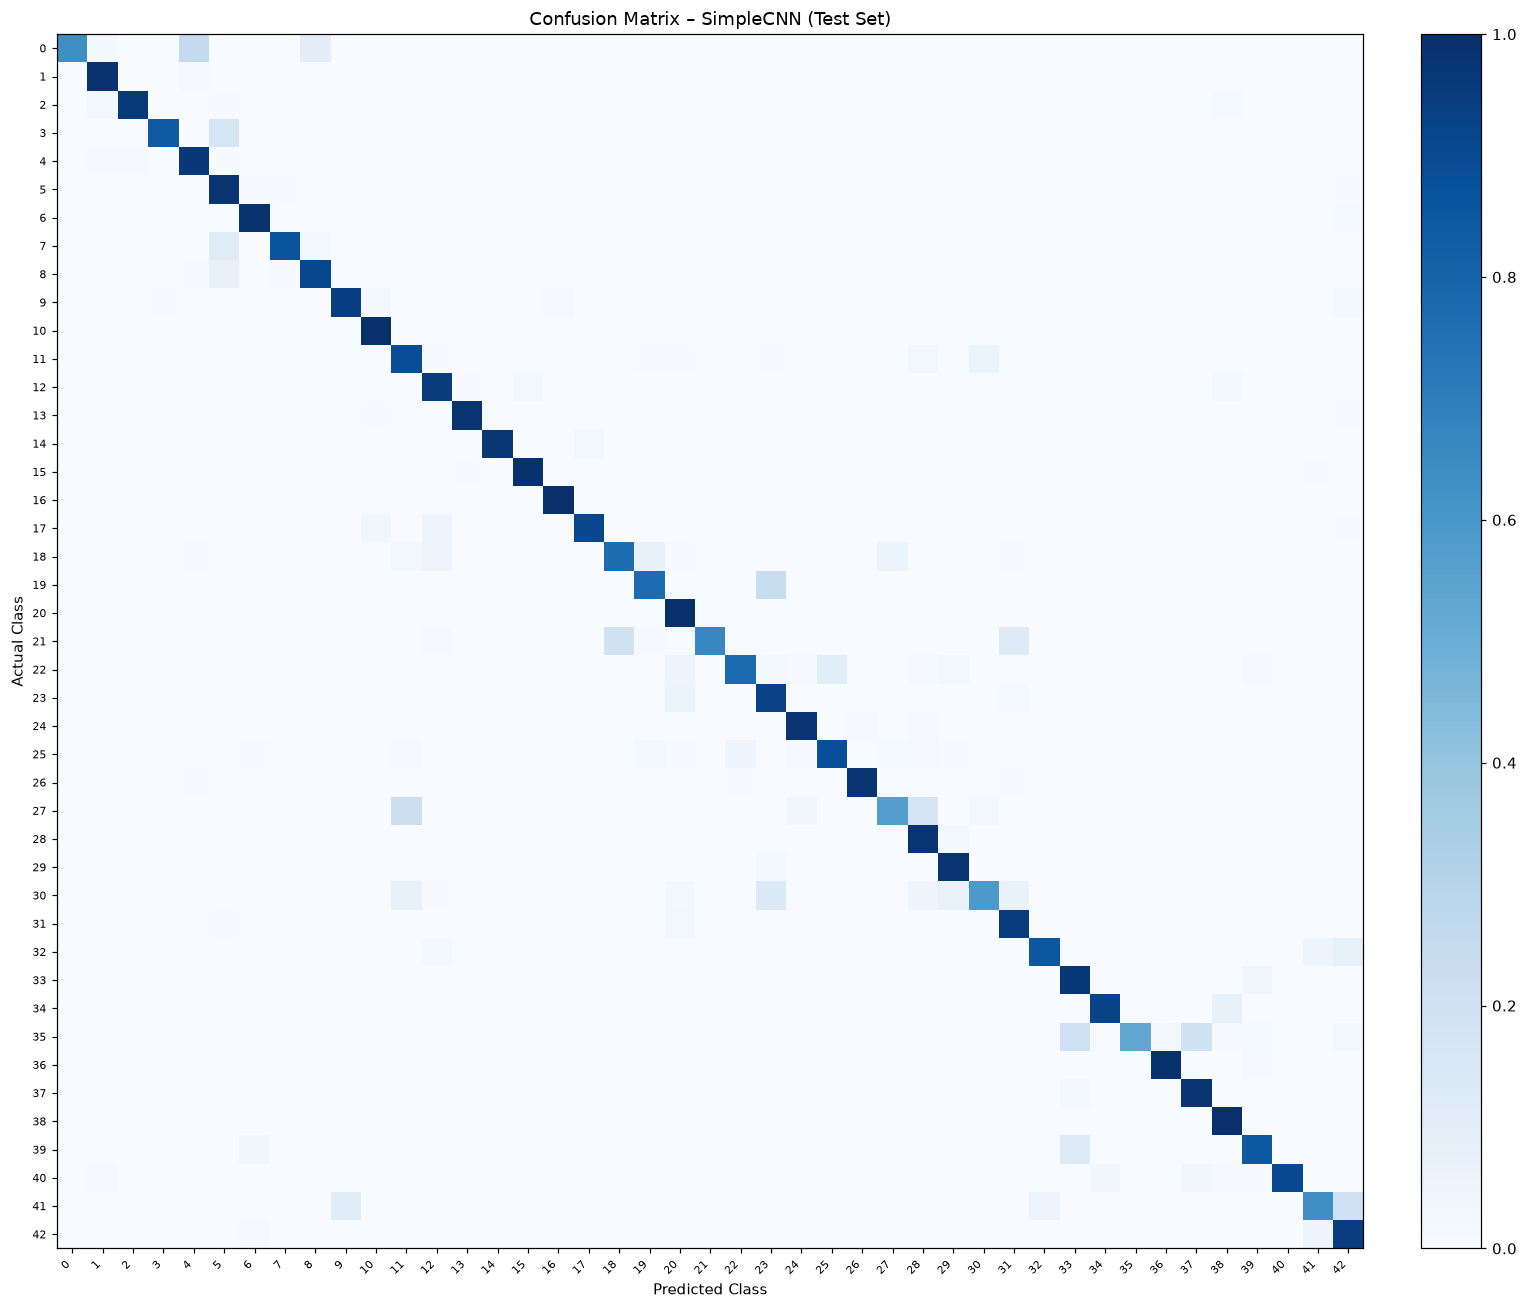

{'web': 'https://www.comet.com/api/asset/download?assetId=b8507492a73641a388b262e1caca9255&experimentKey=1dd0ed01ad694d968e7b30a217044ca7',
 'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=b8507492a73641a388b262e1caca9255&experimentKey=1dd0ed01ad694d968e7b30a217044ca7',
 'assetId': 'b8507492a73641a388b262e1caca9255'}

In [38]:
# 5b: Confusion matrix
metrics = compute_metrics(
    y_true=test_labels,
    y_pred=test_preds,
    num_classes=NUM_CLASSES,
)

cm = metrics["confusion_matrix"]

# Plot normalised confusion matrix
class_names_short = [str(i) for i in range(NUM_CLASSES)]
fig_cm = plot_confusion_matrix(
    cm,
    class_names=class_names_short,
    normalise=True,
    title="Confusion Matrix – SimpleCNN (Test Set)",
)
experiment.log_figure("confusion_matrix", fig_cm)
plt.show()

# Log an interactive confusion matrix to CometML
experiment.log_confusion_matrix(
    y_true=test_labels,
    y_predicted=test_preds,
    labels=class_names_short,
    title="Confusion Matrix – SimpleCNN (Test Set)",
)


In [39]:
# 5c: Print all metrics
print("=" * 55)
print(f"{'Metric':<30} {'Value':>10}")
print("=" * 55)
print(f"{'Accuracy':<30} {metrics['accuracy']:>10.4f}")
print("-" * 55)
for avg in ["macro", "micro", "weighted"]:
    print(f"{'Precision (' + avg + ')':<30} {metrics['precision_' + avg]:>10.4f}")
    print(f"{'Recall (' + avg + ')':<30} {metrics['recall_' + avg]:>10.4f}")
    print(f"{'F1-Score (' + avg + ')':<30} {metrics['f1_' + avg]:>10.4f}")
    print("-" * 55)

# Log all scalar metrics to CometML
experiment.log_metrics({
    "test_accuracy":        metrics["accuracy"],
    "test_f1_macro":        metrics["f1_macro"],
    "test_f1_micro":        metrics["f1_micro"],
    "test_f1_weighted":     metrics["f1_weighted"],
    "test_precision_macro": metrics["precision_macro"],
    "test_recall_macro":    metrics["recall_macro"],
})


Metric                              Value
Accuracy                           0.9173
-------------------------------------------------------
Precision (macro)                  0.8799
Recall (macro)                     0.8869
F1-Score (macro)                   0.8730
-------------------------------------------------------
Precision (micro)                  0.9173
Recall (micro)                     0.9173
F1-Score (micro)                   0.9173
-------------------------------------------------------
Precision (weighted)               0.9289
Recall (weighted)                  0.9173
F1-Score (weighted)                0.9171
-------------------------------------------------------


In [40]:
# 5d: Per-class report and top 5 most confused pairs
from elec5308.metrics import top_confused_pairs, classification_report_df

# Per-class metrics
report_df = classification_report_df(
    test_labels,
    test_preds,
    class_names=list(GTSRB_CLASSES.values()),
)

print("\nPer-class Classification Report (top 10 by support):")
display(report_df.sort_values("support", ascending=False).head(10))

# Required: top 5 most confused class pairs
confused = top_confused_pairs(
    cm,
    class_names=list(GTSRB_CLASSES.values()),
    k=5,
)

print("\nTop 5 Most Confused Class Pairs:")
display(confused)

# Log the table as text for traceability
experiment.log_text(
    confused.to_string(index=False),
    metadata={"context": "top_5_confused_pairs"},
)



Per-class Classification Report (top 10 by support):


,precision,recall,f1-score,support
class,,,,
weighted avg,0.9289,0.9173,0.9171,12630.0
macro avg,0.8799,0.8869,0.8730,12630.0
Speed limit (50 km/h),0.9890,0.9587,0.9736,750.0
Speed limit (30 km/h),0.9660,0.9861,0.9759,720.0
Yield,0.9916,0.9806,0.9860,720.0
Priority road,0.9371,0.9493,0.9431,690.0
Keep right,0.9464,0.9971,0.9711,690.0
Speed limit (70 km/h),0.9537,0.9667,0.9601,660.0
No passing (>3.5t vehicles),0.9606,0.9985,0.9792,660.0



Top 5 Most Confused Class Pairs:


,actual,predicted,count
0,Ahead only,Turn right ahead,78
1,Ahead only,Go straight or left,74
2,Speed limit (60 km/h),Speed limit (80 km/h),72
3,Speed limit (100 km/h),Speed limit (80 km/h),53
4,Speed limit (120 km/h),Speed limit (80 km/h),33


{'web': 'https://www.comet.com/api/asset/download?assetId=ab6bd7045edb424dbc089a697f362375&experimentKey=1dd0ed01ad694d968e7b30a217044ca7',
 'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=ab6bd7045edb424dbc089a697f362375&experimentKey=1dd0ed01ad694d968e7b30a217044ca7',
 'assetId': 'ab6bd7045edb424dbc089a697f362375'}

---
## Section 6 — Task 5: Transfer Learning 🌟

### Background
Instead of training from scratch, transfer learning reuses ImageNet features and adapts them to GTSRB.

Strategy used here:
1. Load a pretrained ResNet-18 and replace its final classifier for 43 GTSRB classes.
2. First train only the new classifier while the backbone is frozen.
3. Then unfreeze the network and fine-tune it using a much smaller learning rate.
4. Use `image_size=64` and ImageNet normalisation throughout.
5. Evaluate the best fine-tuned checkpoint on the test set and save the numeric metrics.

This two-stage procedure keeps the required transfer-learning setup but allows the ImageNet features to adapt to traffic signs.


In [ ]:
# 6a: Load pretrained ResNet-18 with a GTSRB classifier

RUN_TRANSFER_LEARNING = True

torch.manual_seed(2026)
np.random.seed(2026)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(2026)

# Start with a frozen ImageNet backbone as required by the task.
resnet_model = get_pretrained_resnet(
    num_classes=NUM_CLASSES,
    freeze_backbone=True,
)
resnet_model = resnet_model.to(DEVICE)

assert resnet_model is not None, "Transfer-learning model was not created"

tl_trainable_params_head = sum(
    p.numel() for p in resnet_model.parameters() if p.requires_grad
)
tl_total_params = sum(p.numel() for p in resnet_model.parameters())

print("Transfer-learning model created: ResNet-18")
print(f"Initially trainable parameters: {tl_trainable_params_head:,}")
print(f"Total parameters              : {tl_total_params:,}")


In [ ]:
# 6b: Create a NEW CometML experiment for transfer learning

experiment_tl = comet_ml.Experiment(
    api_key=COMET_API_KEY,
    project_name=COMET_PROJECT,
    workspace=COMET_WORKSPACE,
    auto_param_logging=True,
    auto_metric_logging=False,
)

experiment_tl.add_tags(["lab2", "transfer-learning", "resnet18", "gtsrb", "fine-tuned"])
experiment_tl.set_name("ResNet18-GTSRB-two-stage")

print("Transfer-learning CometML experiment created!")
print(f"View at: {experiment_tl.url}")


In [ ]:
# 6c: Transfer-learning DataLoaders and hyperparameters

IMAGE_SIZE_TL = 64
BATCH_SIZE_TL = 32

# Stage 1: learn the new classifier head.
LR_HEAD_TL = 1e-3
HEAD_EPOCHS_TL = 5

# Stage 2: fine-tune the full network with a much smaller learning rate.
LR_FINETUNE_TL = 1e-4
FINETUNE_EPOCHS_TL = 10
WEIGHT_DECAY_TL = 1e-4
N_EPOCHS_TL = HEAD_EPOCHS_TL + FINETUNE_EPOCHS_TL

# Keep augmentation mild because traffic-sign orientation/shape carries meaning.
train_transform_tl = T.Compose([
    T.Resize((IMAGE_SIZE_TL, IMAGE_SIZE_TL)),
    T.RandomRotation(degrees=5),
    T.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
    ),
    T.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.05,
    ),
    T.ToTensor(),
    T.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])

# Validation/test transforms are deterministic.
eval_transform_tl = T.Compose([
    T.Resize((IMAGE_SIZE_TL, IMAGE_SIZE_TL)),
    T.ToTensor(),
    T.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])

train_loader_tl, val_loader_tl, test_loader_tl = load_gtsrb(
    root="./data",
    image_size=IMAGE_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    val_fraction=VAL_SPLIT,
    train_transform=train_transform_tl,
    eval_transform=eval_transform_tl,
    num_workers=NUM_WORKERS,
    seed=2026,
    use_imagenet_stats=True,
)

images_tl, labels_tl = next(iter(train_loader_tl))
assert images_tl.shape[1:] == (3, IMAGE_SIZE_TL, IMAGE_SIZE_TL)
assert labels_tl.min().item() >= 0 and labels_tl.max().item() < NUM_CLASSES

experiment_tl.log_parameters({
    "backbone": "resnet18",
    "image_size": IMAGE_SIZE_TL,
    "batch_size": BATCH_SIZE_TL,
    "head_epochs": HEAD_EPOCHS_TL,
    "head_learning_rate": LR_HEAD_TL,
    "finetune_epochs": FINETUNE_EPOCHS_TL,
    "finetune_learning_rate": LR_FINETUNE_TL,
    "weight_decay": WEIGHT_DECAY_TL,
    "total_epochs": N_EPOCHS_TL,
})

print(
    f"Transfer-learning dataset sizes: "
    f"train={len(train_loader_tl.dataset):,}, "
    f"val={len(val_loader_tl.dataset):,}, "
    f"test={len(test_loader_tl.dataset):,}"
)


In [ ]:
# Train transfer learning in TWO stages

criterion_tl = nn.CrossEntropyLoss()

# ---------------------------------------------------------
# Stage 1 — frozen backbone, train only the classifier head
# ---------------------------------------------------------
optimiser_tl_head = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=LR_HEAD_TL,
    weight_decay=WEIGHT_DECAY_TL,
)

trainer_tl_head = Trainer(
    model=resnet_model,
    optimiser=optimiser_tl_head,
    criterion=criterion_tl,
    device=DEVICE,
    experiment=experiment_tl,
    checkpoint_dir="./checkpoints/resnet18_head",
)

history_tl_head = trainer_tl_head.fit(
    train_loader=train_loader_tl,
    val_loader=val_loader_tl,
    epochs=HEAD_EPOCHS_TL,
    save_best=True,
)
trainer_tl_head.load_best()

print(
    f"Stage 1 complete — best validation accuracy: "
    f"{trainer_tl_head._best_val_acc:.4f}"
)

# ---------------------------------------------------------
# Stage 2 — unfreeze and fine-tune all ResNet-18 parameters
# ---------------------------------------------------------
# This is the important accuracy fix.  Training only the final layer left the
# model around 46% test accuracy because ImageNet features were not adapted
# enough to small 64x64 traffic signs.
for p in resnet_model.parameters():
    p.requires_grad = True

tl_trainable_params_finetune = sum(
    p.numel() for p in resnet_model.parameters() if p.requires_grad
)

optimiser_tl_finetune = torch.optim.AdamW(
    resnet_model.parameters(),
    lr=LR_FINETUNE_TL,
    weight_decay=WEIGHT_DECAY_TL,
)

trainer_tl_finetune = Trainer(
    model=resnet_model,
    optimiser=optimiser_tl_finetune,
    criterion=criterion_tl,
    device=DEVICE,
    experiment=experiment_tl,
    checkpoint_dir="./checkpoints/resnet18_finetuned",
)

history_tl_finetune = trainer_tl_finetune.fit(
    train_loader=train_loader_tl,
    val_loader=val_loader_tl,
    epochs=FINETUNE_EPOCHS_TL,
    save_best=True,
)
trainer_tl_finetune.load_best()

# Use the fine-tuned trainer/model for all downstream evaluation.
trainer_tl = trainer_tl_finetune
optimiser_tl = optimiser_tl_finetune
history_tl = history_tl_finetune

experiment_tl.log_parameters({
    "finetune_trainable_parameters": tl_trainable_params_finetune,
    "two_stage_training": True,
})

print(
    f"Stage 2 complete — best validation accuracy: "
    f"{trainer_tl._best_val_acc:.4f}"
)


In [ ]:
# 6d: Evaluate the BEST fine-tuned ResNet-18 checkpoint

tl_loss, tl_acc, tl_preds, tl_labels = trainer_tl.evaluate(test_loader_tl)

tl_metrics = compute_metrics(
    y_true=tl_labels,
    y_pred=tl_preds,
    num_classes=NUM_CLASSES,
)

tl_loss = float(tl_loss)
tl_acc = float(tl_acc)

assert np.isfinite(tl_acc), "Transfer-learning test accuracy is not finite"
assert 0.0 <= tl_acc <= 1.0, "Transfer-learning test accuracy must be in [0, 1]"

experiment_tl.log_metrics({
    "test_loss": tl_loss,
    "test_accuracy": tl_acc,
    "test_f1_macro": float(tl_metrics["f1_macro"]),
    "test_f1_micro": float(tl_metrics["f1_micro"]),
    "test_f1_weighted": float(tl_metrics["f1_weighted"]),
})

print("\nModel Comparison")
print("=" * 52)
print(f"{'Metric':<22} {'SimpleCNN':>12} {'ResNet-TL':>12}")
print("-" * 52)
print(f"{'Test Accuracy':<22} {test_acc:>12.2%} {tl_acc:>12.2%}")
print(
    f"{'F1 Macro':<22} "
    f"{metrics['f1_macro']:>12.4f} "
    f"{tl_metrics['f1_macro']:>12.4f}"
)
print(
    f"{'F1 Weighted':<22} "
    f"{metrics['f1_weighted']:>12.4f} "
    f"{tl_metrics['f1_weighted']:>12.4f}"
)
print("=" * 52)

# The Gradescope traceback shows the numeric assertion is >= 0.50.
# Stop locally if the model is still below that threshold so a bad
# submission.json is not produced accidentally.
assert tl_acc >= 0.50, (
    f"Transfer-learning accuracy is {tl_acc:.2%}, still below the "
    "Gradescope threshold of 50%. Do not submit yet."
)

experiment_tl.end()


---
## Section 7 — Milestone Submission

This cell collects all required outputs into `submission.json`.  
**Commit this file in the repository** and submit the repository to GitHub.

> ⚠️ Make sure you have run all tasks above before running this cell or it will result in errors.


In [ ]:
# Collect milestone results

import json
import datetime

def safe_get(d, key, default=None):
    try:
        return d[key]
    except (KeyError, TypeError):
        return default

# Task 5 was completed, therefore these must be real numeric values.
assert tl_acc is not None, "Task 5 incomplete: tl_acc is None"
assert tl_metrics is not None, "Task 5 incomplete: tl_metrics is None"

submission = {
    "username": "tanmay-rale",
    "timestamp": datetime.datetime.now().isoformat(),
    "lab": "lab2",
    "comet_url": getattr(experiment, "url", ""),

    # Milestone 1: Dataset
    "M1_num_classes": NUM_CLASSES,
    "M1_train_size": len(train_loader.dataset),
    "M1_val_size": len(val_loader.dataset),
    "M1_test_size": len(test_loader.dataset),

    # Milestone 2: Model
    "M2_model_name": type(model).__name__,
    "M2_param_count": count_parameters(model),

    # Milestone 3: Training
    "M3_best_val_acc": float(trainer._best_val_acc),
    "M3_n_epochs": N_EPOCHS,
    "M3_final_train_loss": float(safe_get(history, "train_loss", [None])[-1]),

    # Milestone 4: Metrics
    "M4_test_accuracy": float(safe_get(metrics, "accuracy")),
    "M4_f1_macro": float(safe_get(metrics, "f1_macro")),
    "M4_f1_micro": float(safe_get(metrics, "f1_micro")),
    "M4_f1_weighted": float(safe_get(metrics, "f1_weighted")),
    "M4_precision_macro": float(safe_get(metrics, "precision_macro")),
    "M4_recall_macro": float(safe_get(metrics, "recall_macro")),

    # Milestone 5: Transfer Learning — best fine-tuned checkpoint
    "M5_tl_test_accuracy": float(tl_acc),
    "M5_tl_f1_macro": float(safe_get(tl_metrics, "f1_macro")),
}

with open("submission.json", "w", encoding="utf-8") as f:
    json.dump(submission, f, indent=2)

print("submission.json saved!")
print("\nMilestone Summary:")
print(
    f"  M1 Dataset    : {NUM_CLASSES} classes | "
    f"train={submission['M1_train_size']:,} | "
    f"val={submission['M1_val_size']:,} | "
    f"test={submission['M1_test_size']:,}"
)
print(
    f"  M2 Model      : {submission['M2_model_name']} | "
    f"{submission['M2_param_count']:,} params"
)
print(
    f"  M3 Training   : best val acc = "
    f"{submission['M3_best_val_acc']:.4f}"
)
print(
    f"  M4 Metrics    : test acc = "
    f"{submission['M4_test_accuracy']:.4f} | "
    f"F1-macro = {submission['M4_f1_macro']:.4f}"
)
print(
    f"  M5 Transfer   : test acc = "
    f"{submission['M5_tl_test_accuracy']:.4f} | "
    f"F1-macro = {submission['M5_tl_f1_macro']:.4f}"
)

print("\nCommit BOTH submission.json and the completed notebook before resubmitting.")

# End baseline experiment after all metrics have been collected.
experiment.end()


---
## 📚 Resources

| Resource | Link |
|---|---|
| GTSRB dataset paper | Stallkamp et al., IJCNN 2011 |
| PyTorch docs | [pytorch.org/docs](https://pytorch.org/docs) |
| torchvision transforms | [pytorch.org/vision/transforms](https://pytorch.org/vision/stable/transforms.html) |
| CometML quick-start | [comet.ml/docs/quick-start](https://www.comet.ml/docs/quick-start/) |
| Scikit-learn metrics | [scikit-learn.org/metrics](https://scikit-learn.org/stable/modules/model_evaluation.html) |

---
*ELEC5308 Lab 2 | University of Sydney | School of Electrical and Computer Engineering*
